### 1. IMPORTAR LIBRERÍAS

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import tensorflow.keras.backend as K

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


### 2. PARÁMETROS

In [ ]:
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 75
NUM_CLASSES   = 10        
NOMBRE_MODELO = 'densenet201_desde_plantvillage'

# Fase 1 (cabeza congelada)
PATIENCE_ES_F1 = 10
PATIENCE_LR_F1 = 5

# Fase 2 (fine-tuning)
PATIENCE_ES_F2 = 15
PATIENCE_LR_F2 = 8

# Ruta de los pesos entrenados en PlantVillage
PESOS_PLANTVILLAGE = '../../PlantVillage_Sin_FT/pesos_densenet201/densenet201_backbone_plantvillage.h5'

In [3]:
# Confirmar que el archivo de pesos existe

if os.path.exists(PESOS_PLANTVILLAGE):
    print(f"Archivo de pesos encontrado: {PESOS_PLANTVILLAGE}")
    tamano_mb = os.path.getsize(PESOS_PLANTVILLAGE) / (1024 * 1024)
    print(f"   Tamaño: {tamano_mb:.2f} MB")
else:
    print(f"ERROR: No se encontró el archivo: {PESOS_PLANTVILLAGE}")
    print("Revisa la ruta antes de continuar.")

Archivo de pesos encontrado: ../../PlantVillage_Sin_FT/pesos_densenet201/densenet201_backbone_plantvillage.h5
   Tamaño: 71.41 MB


### 3. PREPROCESAMIENTO

In [4]:
base_dir  = '../../../Data/Cana_de_azucar'
train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'val')
test_dir  = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Imágenes de entrenamiento : {train_generator.samples}')
print(f'Imágenes de validación    : {val_generator.samples}')
print(f'Imágenes de test          : {test_generator.samples}')


Found 6112 images belonging to 10 classes.
Found 1309 images belonging to 10 classes.
Found 1309 images belonging to 10 classes.
Imágenes de entrenamiento : 6112
Imágenes de validación    : 1309
Imágenes de test          : 1309


### 4. CONSTRUCCIÓN DEL MODELO

In [ ]:
# Crear el backbone vacío (sin pesos), se cargaran manualmente
base_model = DenseNet201(
    weights=None,
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Cargar los pesos que el modelo aprendió en PlantVillage
base_model.load_weights(PESOS_PLANTVILLAGE)
print("Pesos de PlantVillage cargados correctamente en el backbone")

# Congelar el backbone para la Fase 1
base_model.trainable = False

# Cabeza clasificadora para TUS 10 clases de caña
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)
    ),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')   # 10 clases
], name=NOMBRE_MODELO)

model.summary()

Pesos de PlantVillage cargados correctamente en el backbone
Model: "densenet201_desde_plantvillage"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 densenet201 (Functional)    (None, 7, 7, 1920)        18321984  
                                                                 
 global_average_pooling2d (G  (None, 1920)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               245888    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 18,569,162
Trainable params:

### 5. COMPILAR EL MODELO

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 6. ENTRENAMIENTO

#### 6.1 Fase 1: entrenar solo la cabeza (backbone congelado):

In [7]:
print('FASE 1: Entrenando cabeza clasificadora (backbone congelado)')

early_stopping_fase1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE_ES_F1,
    restore_best_weights=True,
    verbose=1
)

checkpoint_fase1 = tf.keras.callbacks.ModelCheckpoint(
    filepath=f'{NOMBRE_MODELO}_fase1_weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

reduce_lr_fase1 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=PATIENCE_LR_F1,
    min_lr=1e-6,
    verbose=1
)

history_fase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping_fase1, checkpoint_fase1, reduce_lr_fase1]
)

print(f'\nFase 1 completada.')
print(f'Mejor val_accuracy fase 1: {max(history_fase1.history["val_accuracy"]):.4f}')

FASE 1: Entrenando cabeza clasificadora (backbone congelado)
Epoch 1/75
191/191 [==============================] - ETA: 0s - loss: 1.1450 - accuracy: 0.6405
Epoch 1: val_loss improved from inf to 0.61043, saving model to densenet201_desde_plantvillage_fase1_weights.h5
191/191 [==============================] - 471s 2s/step - loss: 1.1450 - accuracy: 0.6405 - val_loss: 0.6104 - val_accuracy: 0.8304 - lr: 0.0010
Epoch 2/75
191/191 [==============================] - ETA: 0s - loss: 0.7249 - accuracy: 0.7726
Epoch 2: val_loss improved from 0.61043 to 0.49159, saving model to densenet201_desde_plantvillage_fase1_weights.h5
191/191 [==============================] - 456s 2s/step - loss: 0.7249 - accuracy: 0.7726 - val_loss: 0.4916 - val_accuracy: 0.8556 - lr: 0.0010
Epoch 3/75
191/191 [==============================] - ETA: 0s - loss: 0.6187 - accuracy: 0.8153
Epoch 3: val_loss improved from 0.49159 to 0.47011, saving model to densenet201_desde_plantvillage_fase1_weights.h5
191/191 [========

#### 6.2 Fase 2 (fine-tuning, últimas 30 capas descongeladas):

In [8]:
# Cargar explícitamente los mejores pesos de Fase 1 
model.load_weights(f'{NOMBRE_MODELO}_fase1_weights.h5')
print("Mejores pesos de Fase 1 cargados desde disco")


# Descongelar todo el backbone
base_model.trainable = True

# Recongelar todas excepto las últimas 30 capas
CAPAS_A_CONGELAR = len(base_model.layers) - 30

for i, layer in enumerate(base_model.layers):
    layer.trainable = (i >= CAPAS_A_CONGELAR)

print('FASE 2: Fine-tuning (últimas 30 capas descongeladas)')
print(f'Total capas en backbone  : {len(base_model.layers)}')
print(f'Capas congeladas         : {CAPAS_A_CONGELAR}')
print(f'Capas descongeladas      : {len(base_model.layers) - CAPAS_A_CONGELAR}')

# Solo cambiamos el learning rate, SIN recompilar
# (recompilar reiniciaría el estado interno del optimizador Adam)
K.set_value(model.optimizer.learning_rate, 1e-5)

early_stopping_fase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE_ES_F2,
    restore_best_weights=True,
    verbose=1
)

checkpoint_fase2 = tf.keras.callbacks.ModelCheckpoint(
    filepath=f'{NOMBRE_MODELO}_weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

reduce_lr_fase2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=PATIENCE_LR_F2,
    min_lr=1e-6,
    verbose=1
)

history_fase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping_fase2, checkpoint_fase2, reduce_lr_fase2]
)

print(f'\nFase 2 completada.')
print(f'Mejor val_accuracy fase 2: {max(history_fase2.history["val_accuracy"]):.4f}')

Mejores pesos de Fase 1 cargados desde disco
FASE 2: Fine-tuning (últimas 30 capas descongeladas)
Total capas en backbone  : 707
Capas congeladas         : 677
Capas descongeladas      : 30
Epoch 1/75
191/191 [==============================] - ETA: 0s - loss: 0.2085 - accuracy: 0.9552
Epoch 1: val_loss improved from inf to 0.17367, saving model to densenet201_desde_plantvillage_weights.h5
191/191 [==============================] - 450s 2s/step - loss: 0.2085 - accuracy: 0.9552 - val_loss: 0.1737 - val_accuracy: 0.9664 - lr: 1.0000e-05
Epoch 2/75
191/191 [==============================] - ETA: 0s - loss: 0.1970 - accuracy: 0.9599
Epoch 2: val_loss did not improve from 0.17367
191/191 [==============================] - 447s 2s/step - loss: 0.1970 - accuracy: 0.9599 - val_loss: 0.1744 - val_accuracy: 0.9679 - lr: 1.0000e-05
Epoch 3/75
191/191 [==============================] - ETA: 0s - loss: 0.1933 - accuracy: 0.9612
Epoch 3: val_loss did not improve from 0.17367
191/191 [===============

### 7. Curvas de entrenamiento (combinando Fase 1 + Fase 2):

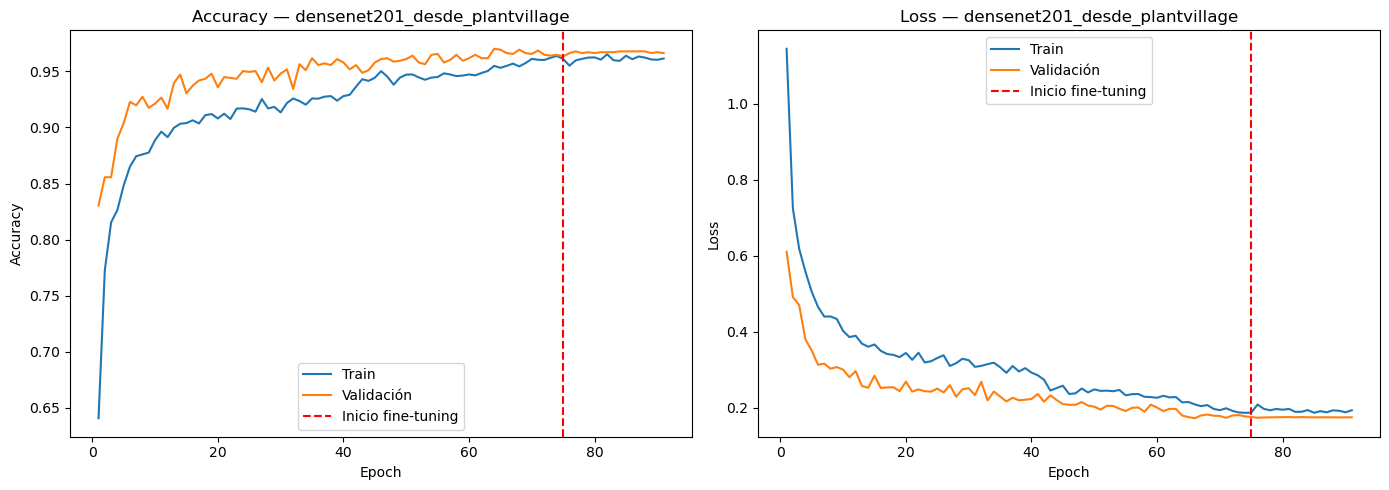

In [9]:
acc      = history_fase1.history['accuracy']     + history_fase2.history['accuracy']
val_acc  = history_fase1.history['val_accuracy'] + history_fase2.history['val_accuracy']
loss     = history_fase1.history['loss']         + history_fase2.history['loss']
val_loss = history_fase1.history['val_loss']     + history_fase2.history['val_loss']

epochs_total = range(1, len(acc) + 1)
corte        = len(history_fase1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_total, acc,     label='Train')
ax1.plot(epochs_total, val_acc, label='Validación')
ax1.axvline(x=corte, color='red', linestyle='--', label='Inicio fine-tuning')
ax1.set_title(f'Accuracy — {NOMBRE_MODELO}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(epochs_total, loss,     label='Train')
ax2.plot(epochs_total, val_loss, label='Validación')
ax2.axvline(x=corte, color='red', linestyle='--', label='Inicio fine-tuning')
ax2.set_title(f'Loss — {NOMBRE_MODELO}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{NOMBRE_MODELO}_curvas.png', dpi=150)
plt.show()

### 8. Evaluación final en test de caña

In [10]:
test_generator.reset()

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

predicciones = model.predict(
    test_generator,
    steps=test_generator.samples // BATCH_SIZE + 1
)
y_pred = np.argmax(predicciones, axis=1)
y_true = test_generator.classes

f1 = f1_score(y_true, y_pred, average='weighted')

print(f'\nTest Accuracy : {test_accuracy:.4f}')
print(f'Test Loss     : {test_loss:.4f}')
print(f'F1 Score      : {f1:.4f}')

nombres_clases = list(test_generator.class_indices.keys())
print('\n--- Reporte de clasificación ---')
print(classification_report(y_true, y_pred, target_names=nombres_clases))

41/41 [==============================] - 78s 2s/step

Test Accuracy : 0.9748
Test Loss     : 0.1556
F1 Score      : 0.9748

--- Reporte de clasificación ---
                  precision    recall  f1-score   support

          carbon       0.99      1.00      0.99        75
   hoja_amarilla       0.99      0.99      0.99       150
   mancha_anillo       0.99      0.98      0.99       106
    mancha_parda       0.97      0.97      0.97       150
         mosaico       0.95      0.99      0.97       150
     muermo_rojo       0.94      0.95      0.94       150
            roya       0.95      0.95      0.95       150
           sanas       0.99      0.95      0.97       150
           secas       1.00      1.00      1.00        78
tizon_bacteriano       0.99      0.99      0.99       150

        accuracy                           0.97      1309
       macro avg       0.98      0.98      0.98      1309
    weighted avg       0.98      0.97      0.97      1309



### 9. Matriz de Confusión

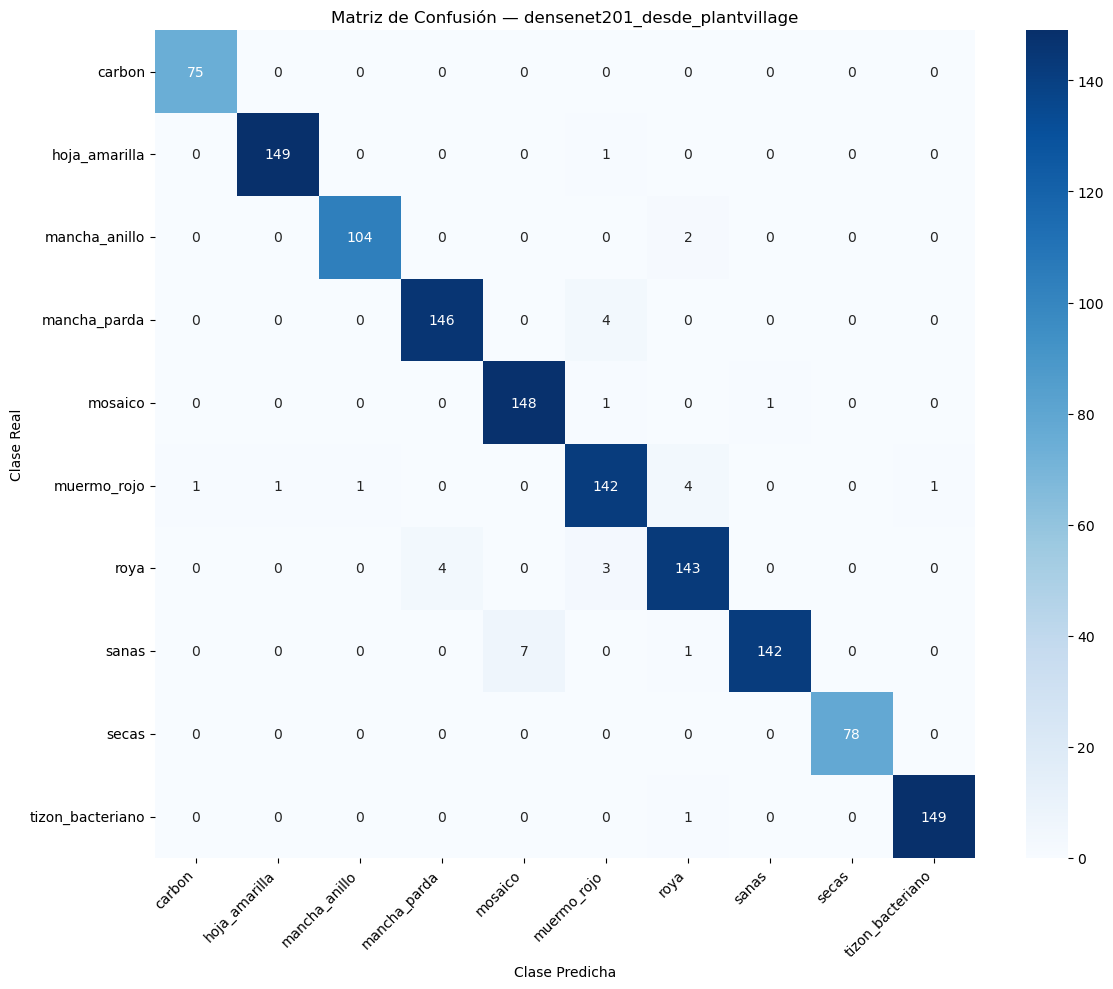

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nombres_clases,
    yticklabels=nombres_clases
)
plt.title(f'Matriz de Confusión — {NOMBRE_MODELO}')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()